In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
import shap

In [3]:
df = pd.read_csv("softball_data.csv")
df.head()

,Player,POS,BA_Home,OBP_Home,SLG_Home,OPS_Home,GP_Home,PA_Home,AB_Home,R_Home,...,HR_Away,RBI_Away,HBP_Away,BB_Away,K_Away,SB_Away,CS_Away,PS,WS,P4
0,Morgan Petty,RF,0.545,0.643,0.939,1.582,12,42,33,10,...,2,8,8,4,9,8,3,0.185,0,0
1,Ella Squaires,LF,0.475,0.575,0.525,1.101,19,73,59,21,...,0,4,0,3,6,4,2,0.169,0,0
2,Ashley Della Guardia,1B,0.444,0.516,0.833,1.349,19,64,54,16,...,0,3,0,9,6,1,0,0.256,0,0
3,Emily Riggs,2B,0.418,0.492,0.782,1.274,19,63,55,10,...,1,5,1,9,19,0,0,0.236,0,0
4,Caitlyn Mitros,LF,0.417,0.475,0.528,1.003,11,40,36,7,...,0,3,0,4,3,4,2,0.143,0,0


In [4]:
X = df.iloc[:,2:41]
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X = pd.DataFrame(X, columns=scaler.get_feature_names_out())
X.head()

,BA_Home,OBP_Home,SLG_Home,OPS_Home,GP_Home,PA_Home,AB_Home,R_Home,H_Home,2B_Home,...,HR_Away,RBI_Away,HBP_Away,BB_Away,K_Away,SB_Away,CS_Away,PS,WS,P4
0,0.922166,0.980936,0.688416,0.797562,0.235294,0.251908,0.232759,0.222222,0.310345,0.1250,...,0.133333,0.222222,0.533333,0.173913,0.333333,0.380952,0.428571,0.788288,0.0,0.0
1,0.803723,0.863085,0.384897,0.542660,0.441176,0.488550,0.456897,0.466667,0.482759,0.1875,...,0.000000,0.111111,0.000000,0.130435,0.222222,0.190476,0.285714,0.764264,0.0,0.0
2,0.751269,0.760832,0.610704,0.674086,0.441176,0.419847,0.413793,0.355556,0.413793,0.1875,...,0.000000,0.083333,0.000000,0.391304,0.222222,0.047619,0.000000,0.894895,0.0,0.0
3,0.707276,0.719237,0.573314,0.634340,0.441176,0.412214,0.422414,0.222222,0.396552,0.3125,...,0.066667,0.138889,0.066667,0.391304,0.703704,0.000000,0.000000,0.864865,0.0,0.0
4,0.705584,0.689775,0.387097,0.490726,0.205882,0.236641,0.258621,0.155556,0.258621,0.1250,...,0.000000,0.083333,0.000000,0.173913,0.111111,0.190476,0.285714,0.725225,0.0,0.0


In [19]:
isof = IsolationForest(contamination=0.01)
isof.fit(X)

IsolationForest(contamination=0.01)

In [20]:
outlier = isof.predict(X)

In [21]:
Xdf = X.copy()
Xdf['outlier'] = (outlier == -1).astype(int)

In [22]:
df[outlier == -1]

,Player,POS,BA_Home,OBP_Home,SLG_Home,OPS_Home,GP_Home,PA_Home,AB_Home,R_Home,...,HR_Away,RBI_Away,HBP_Away,BB_Away,K_Away,SB_Away,CS_Away,PS,WS,P4
43,Addison Barnard,CF,0.481,0.569,1.352,1.921,19,66,54,23,...,9,18,0,23,7,4,4,0.098,0,0
200,Cori McMillan,RF,0.469,0.565,1.061,1.626,17,62,49,25,...,10,28,1,13,12,6,0,0.104,0,1
204,Jaysoni Beachum,3B,0.439,0.508,0.785,1.293,35,128,107,34,...,4,17,2,11,3,1,0,0.066,0,1
208,Claire Davidson,LF,0.419,0.534,0.872,1.407,32,118,86,33,...,6,22,1,10,8,1,1,0.005,1,1
242,Amaya Ross,1B,0.337,0.464,0.652,1.115,35,111,89,40,...,3,10,0,9,10,5,3,0.029,0,1
400,Jayda Coleman,CF,0.466,0.580,0.822,1.402,29,102,73,31,...,5,14,2,20,2,1,0,0.062,1,1
401,Reese Atwood,C,0.465,0.560,0.907,1.467,31,109,86,22,...,9,35,4,8,4,1,1,0.106,1,1
404,Alyssa Brito,3B,0.440,0.543,0.905,1.448,30,105,84,26,...,6,15,0,7,4,0,0,0.078,1,1
425,Mia Scott,3B,0.388,0.486,0.729,1.215,31,108,85,34,...,4,29,0,10,4,2,0,-0.055,1,1
427,Kayden Henry,CF,0.378,0.398,0.533,0.931,31,94,90,23,...,4,13,0,10,11,14,1,-0.012,1,1


In [23]:
scores = isof.decision_function(X)

In [24]:
model = RandomForestRegressor()
model.fit(X, scores)

RandomForestRegressor()

In [25]:
explainer = shap.Explainer(model, X)
shap_values = explainer(X, check_additivity = False)
exp = shap.Explanation(shap_values, shap_values.base_values, X, feature_names = X.columns)

 99%|===================| 2298/2318 [01:58<00:01]        

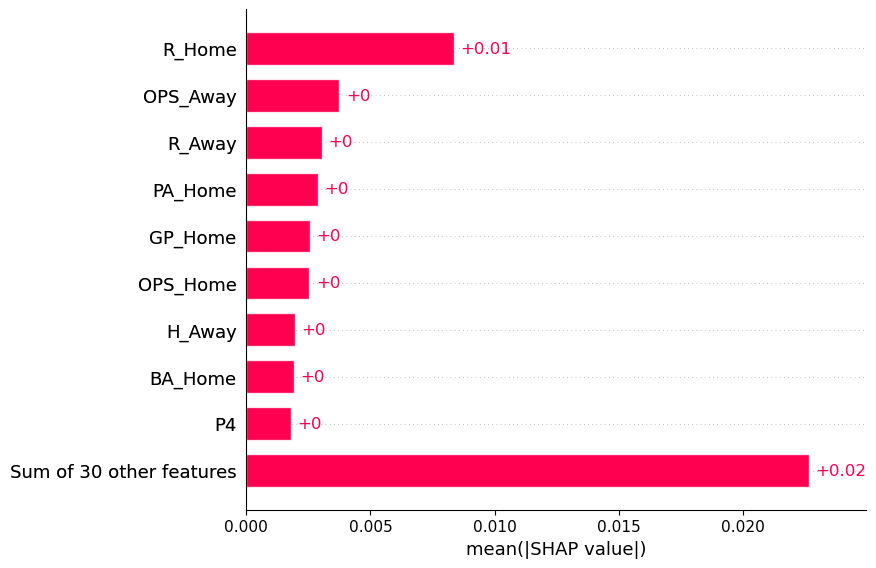

In [26]:
shap.plots.bar(exp)

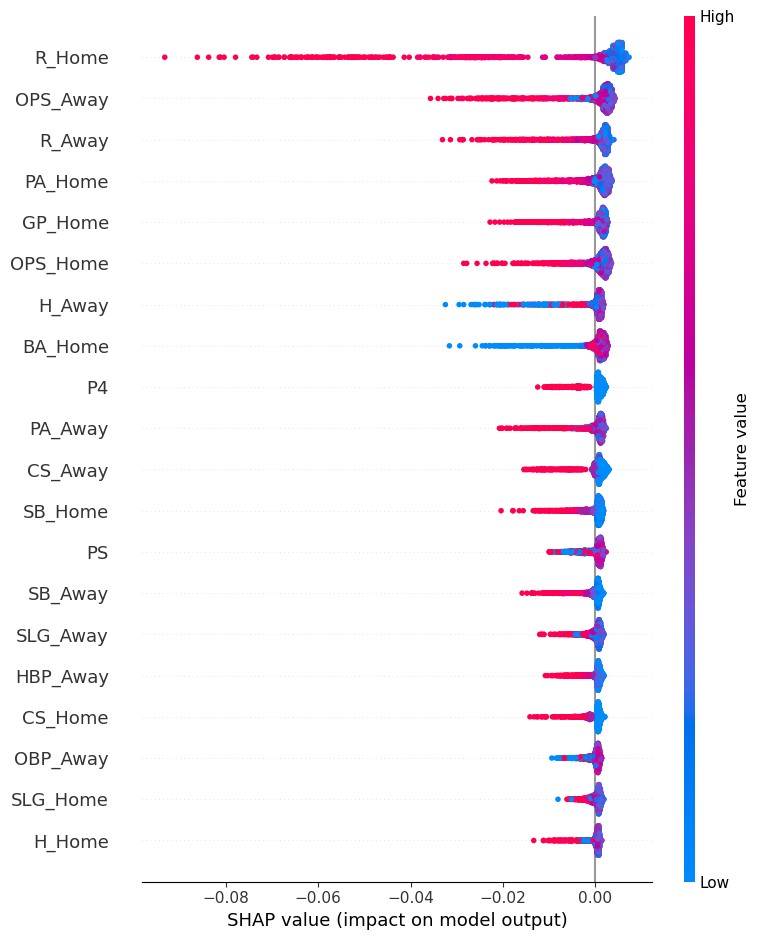

In [27]:
shap.summary_plot(exp)